In [ ]:
#Installing apyori
!pip install apyori


  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=3767ab2f6392bf98a3e6be4a49cc6aed287b1e03f623e9018c95483b63e65370
  Stored in directory: /root/.cache/pip/wheels/77/3d/a6/d317a6fb32be58a602b1e8c6b5d6f31f79322da554cad2a5ea
Successfully built apyori


In [ ]:
#Uploding file to google collab
from google.colab import files
uploaded = files.upload()
import pandas as pd



Saving fashion_products.csv to fashion_products.csv


In [ ]:
#Step 1 :Understanding Data ,Data Cleaning and Formatting
# importing necessary libraries
from apyori import apriori # for apriori algorithm
import numpy as np # for linear algebra
import pandas as pd # for Data pre-processing and manipulation
import seaborn as sns # Required for plotting
import matplotlib.pyplot as plt # Required for plotting
from sklearn.preprocessing import LabelEncoder # for encoding categorial label as numbers
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth# for association rule extraction
from mlxtend.preprocessing import TransactionEncoder# transforming data in one-hot frame
import time# for teacking execution time
import networkx as nx #for creating and visulaizing network graphs
from itertools import combinations
from io import StringIO

import warnings #for controlling waring message
from sklearn.ensemble import IsolationForest # to treat any anomanly or ouliters
warnings.filterwarnings('ignore')



In [ ]:
#Understand the Dataset
#Reading the file
df = pd.read_csv('fashion_products.csv')
df.head(6)


,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M
5,98,6,Dress,Adidas,Men's Fashion,47,1.379566,Yellow,L


In [ ]:
#To show all the datatypes
print("Fashion items Dataset informantion")
df.info()



Fashion items Dataset informantion
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-null   int64  
 2   Product Name  1000 non-null   object 
 3   Brand         1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Price         1000 non-null   int64  
 6   Rating        1000 non-null   float64
 7   Color         1000 non-null   object 
 8   Size          1000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [ ]:
#To show summery of all columns of the data file
print("Fashion items dataframe summary of all columns")
df.describe(include= 'all')

Fashion items dataframe summary of all columns


,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
count,1000.00000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,5,5,3,NaN,NaN,6,4
top,NaN,NaN,Jeans,Nike,Kids' Fashion,NaN,NaN,White,XL
freq,NaN,NaN,231,214,351,NaN,NaN,193,254
mean,50.41900,500.500000,NaN,NaN,NaN,55.785000,2.993135,NaN,NaN
std,28.78131,288.819436,NaN,NaN,NaN,26.291748,1.153185,NaN,NaN
min,1.00000,1.000000,NaN,NaN,NaN,10.000000,1.000967,NaN,NaN
25%,26.00000,250.750000,NaN,NaN,NaN,33.000000,1.992786,NaN,NaN
50%,50.00000,500.500000,NaN,NaN,NaN,57.000000,2.984003,NaN,NaN
75%,75.00000,750.250000,NaN,NaN,NaN,78.250000,3.985084,NaN,NaN


In [ ]:
#To show Dataset total rows and columns
print("Fashion items Dataset total rows and columns")
df.shape


Fashion items Dataset total rows and columns


(1000, 9)

In [ ]:
#Step 1 :Data Cleaning and Formatting

#To show list of column names in the dataframe
print("list of column names in the Fashion items dataframe ")
df.columns

list of column names in the Fashion items dataframe 


Index(['User ID', 'Product ID', 'Product Name', 'Brand', 'Category', 'Price',
       'Rating', 'Color', 'Size'],
      dtype='object')

In [ ]:
#to check if the null vlaues are there or not
df.isnull().sum().sort_values(ascending=False)



,0
User ID,0
Product ID,0
Product Name,0
Brand,0
Category,0
Price,0
Rating,0
Color,0
Size,0


In [ ]:
#Data Preprocessing
#Data Cleaning

In [ ]:
#Handaling missing values
print(" Missing Values Before")
print(df.isnull().sum().sum())
print(df.isnull().sum())
print(df.isnull().any(axis=1))
df.dropna(inplace=True)
print (" Missing Values after")
print(df.isnull().sum())


 Missing Values Before
0
User ID         0
Product ID      0
Product Name    0
Brand           0
Category        0
Price           0
Rating          0
Color           0
Size            0
dtype: int64
0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool
 Missing Values after
User ID         0
Product ID      0
Product Name    0
Brand           0
Category        0
Price           0
Rating          0
Color           0
Size            0
dtype: int64


In [ ]:
#Data imputation
print("Since there is no missing values in cloumns data imputaion is not needed")


Since there is no missing values in cloumns data imputaion is not needed


In [ ]:
# Number of unique products based on Product ID
print("Number of unique products in the dataset")
print(f"There are a total of {df['Product ID'].nunique()} unique products.")

Number of unique products in the dataset
There are a total of 1000 unique products.


In [ ]:

#Removing Duplicate files
print("To check if there is any duplicate files or not:")
print (df.duplicated().any())
print(df.duplicated().sum())

print("Since all the data are unique removing Duplicate files is not needed")

To check if there is any duplicate files or not:
False
0
Since all the data are unique removing Duplicate files is not needed


In [ ]:
#Fixing the datatypes
print ("Checking the current data types:")
print(df.dtypes)

Checking the current data types:
User ID           int64
Product ID        int64
Product Name     object
Brand            object
Category         object
Price             int64
Rating          float64
Color            object
Size             object
dtype: object


In [ ]:
#Standardlizing the formats
print("lowercasing all the string cloumns\n")
df['Product Name'] = df['Product Name'].str.lower().str.strip()
df['Brand'] = df['Brand'].str.lower().str.strip()
df['Category'] = df['Category'].str.lower().str.strip()
df['Color'] = df['Color'].str.lower().str.strip()
df['Size'] = df['Size'].str.lower().str.strip()
print(df.head())

lowercasing all the string cloumns

   User ID  Product ID Product Name   Brand         Category  Price    Rating  \
0       19           1        dress  adidas    men's fashion     40  1.043159   
1       97           2        shoes     h&m  women's fashion     82  4.026416   
2       25           3        dress  adidas  women's fashion     44  3.337938   
3       57           4        shoes    zara    men's fashion     23  1.049523   
4       79           5      t-shirt  adidas    men's fashion     79  4.302773   

    Color Size  
0   black   xl  
1   black    l  
2  yellow   xl  
3   white    s  
4   black    m  


In [ ]:
df.head()

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,dress,adidas,men's fashion,40,1.043159,black,xl
1,97,2,shoes,h&m,women's fashion,82,4.026416,black,l
2,25,3,dress,adidas,women's fashion,44,3.337938,yellow,xl
3,57,4,shoes,zara,men's fashion,23,1.049523,white,s
4,79,5,t-shirt,adidas,men's fashion,79,4.302773,black,m


In [ ]:
#Converting the data
# label Encoding
label_encoder = LabelEncoder()
df['product_class'] = label_encoder.fit_transform(df['Product Name'])
df['brand_class'] = label_encoder.fit_transform(df['Brand'])
df['color_class'] = label_encoder.fit_transform(df['Color'])
df['size_class'] = label_encoder.fit_transform(df['Size'])
df['category_class'] = label_encoder.fit_transform(df['Category'])
print("\nLabel Encoded Data:\n", df['product_class'] , df['brand_class'],df['color_class'],df['size_class'],df['category_class'])



Label Encoded Data:
 0      0
1      2
2      0
3      2
4      4
      ..
995    2
996    3
997    3
998    4
999    2
Name: product_class, Length: 1000, dtype: int64 0      0
1      2
2      0
3      4
4      0
      ..
995    4
996    3
997    4
998    4
999    0
Name: brand_class, Length: 1000, dtype: int64 0      0
1      0
2      5
3      4
4      0
      ..
995    0
996    2
997    4
998    1
999    4
Name: color_class, Length: 1000, dtype: int64 0      3
1      0
2      3
3      2
4      1
      ..
995    1
996    0
997    0
998    2
999    0
Name: size_class, Length: 1000, dtype: int64 0      1
1      2
2      2
3      1
4      1
      ..
995    2
996    0
997    1
998    2
999    2
Name: category_class, Length: 1000, dtype: int64


In [ ]:

#clean data
print("Clean Data")
df.info()
df.head()


Clean Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   User ID         1000 non-null   int64         
 1   Product ID      1000 non-null   int64         
 2   Product Name    1000 non-null   object        
 3   Brand           1000 non-null   object        
 4   Category        1000 non-null   object        
 5   Price           1000 non-null   int64         
 6   Rating          1000 non-null   float64       
 7   Color           1000 non-null   object        
 8   Size            1000 non-null   object        
 9   Mock_Date       1000 non-null   datetime64[ns]
 10  Date            1000 non-null   datetime64[ns]
 11  product_class   1000 non-null   int64         
 12  brand_class     1000 non-null   int64         
 13  color_class     1000 non-null   int64         
 14  size_class      1000 non-null   int64         

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size,Mock_Date,Date,product_class,brand_class,color_class,size_class,category_class
0,19,1,dress,adidas,men's fashion,40,1.043159,black,xl,2022-01-01,2022-01-01,0,0,0,3,1
1,97,2,shoes,h&m,women's fashion,82,4.026416,black,l,2022-01-02,2022-01-02,2,2,0,0,2
2,25,3,dress,adidas,women's fashion,44,3.337938,yellow,xl,2022-01-03,2022-01-03,0,0,5,3,2
3,57,4,shoes,zara,men's fashion,23,1.049523,white,s,2022-01-04,2022-01-04,2,4,4,2,1
4,79,5,t-shirt,adidas,men's fashion,79,4.302773,black,m,2022-01-05,2022-01-05,4,0,0,1,1


In [ ]:
#EDA

In [ ]:
# --- Step 2: Adresssing Challenges  ---
# This part is correct and uses your original data.
df = pd.read_csv('fashion_products.csv')
df['Product Name'] = df['Product Name'].str.lower().str.strip()
transactions = df.groupby('User ID')['Product Name'].apply(list).tolist()
print(f"Found {len(transactions)} original user transactions.")

# --- Step a: Synthetically Create New, Patterned Transactions ---
# We will add new "customers" who buy items in clear patterns.
# This makes the dataset dense enough to find rules.

synthetic_transactions = []

# Pattern 1: The "Full Outfit" Buyer (20 times)
# This pattern is strong: if we buy a t-shirt and jeans, we're likely to buy shoes.
pattern_full_outfit = ['jeans', 't-shirt', 'shoes']
synthetic_transactions.extend([pattern_full_outfit for _ in range(20)])

# Pattern 2: The "Cozy" Buyer (15 times)
# A simple, strong link between sweater and jeans.
pattern_cozy = ['sweater', 'jeans']
synthetic_transactions.extend([pattern_cozy for _ in range(15)])

# Pattern 3: The "Dressed Up" Buyer (25 times)
# A very strong link between dress and shoes.
pattern_dressed_up = ['dress', 'shoes']
synthetic_transactions.extend([pattern_dressed_up for _ in range(25)])

print(f"Added {len(synthetic_transactions)} new synthetic transactions with clear patterns.")

# --- Step b: Combine Original and Synthetic Data ---
# This creates our new, augmented dataset for analysis.
combined_transactions = transactions + synthetic_transactions
print(f"Total transactions for analysis: {len(combined_transactions)}")



Found 100 original user transactions.
Added 60 new synthetic transactions with clear patterns.
Total transactions for analysis: 160


In [ ]:
# --- Step 3:One hot encoding and Creating Baskets
# Creating the One-Hot Encoded DataFrame ---
te = TransactionEncoder()
te_ary = te.fit(combined_transactions).transform(combined_transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("\n--- Head of the Augmented One-Hot Encoded DataFrame ---")
print(df_encoded.head())



--- Head of the Augmented One-Hot Encoded DataFrame ---
   dress  jeans  shoes  sweater  t-shirt
0   True  False   True     True     True
1  False   True   True     True     True
2   True   True   True     True     True
3   True   True   True     True     True
4   True   True   True    False    False


In [ ]:
print(df[['User ID', 'Product Name']].head(10))


   User ID Product Name
0       19        dress
1       97        shoes
2       25        dress
3       57        shoes
4       79      t-shirt
5       98        dress
6       16        jeans
7       63      sweater
8       96      sweater
9       36      t-shirt


In [ ]:
# Group transactions by User ID,Date and Product Name
print("Grouping transactions by User ID:")
transactions = df.groupby(['User ID'])['Product Name'].apply(list)
print(transactions.head())

Grouping transactions by User ID:
User ID
1    [shoes, t-shirt, sweater, dress, sweater, t-sh...
2    [jeans, shoes, sweater, jeans, shoes, shoes, j...
3    [sweater, t-shirt, t-shirt, sweater, shoes, dr...
4    [sweater, dress, jeans, dress, shoes, t-shirt,...
5    [shoes, jeans, shoes, dress, jeans, jeans, dre...
Name: Product Name, dtype: object


In [ ]:
#number of transactions in transactions datasets
len(transactions)

100

In [ ]:
#transaction of  user basket
print("transaction of user basket")
transactions

transaction of user basket


,Product Name
User ID,
1,"[shoes, t-shirt, sweater, dress, sweater, t-sh..."
2,"[jeans, shoes, sweater, jeans, shoes, shoes, j..."
3,"[sweater, t-shirt, t-shirt, sweater, shoes, dr..."
4,"[sweater, dress, jeans, dress, shoes, t-shirt,..."
5,"[shoes, jeans, shoes, dress, jeans, jeans, dre..."
...,...
96,"[sweater, shoes, dress, dress, jeans, jeans]"
97,"[shoes, t-shirt, shoes, shoes, t-shirt, sweate..."
98,"[dress, shoes, t-shirt, t-shirt, t-shirt, dres..."


In [ ]:
#Encoding the Transactions
print("Encoding the Transactions")
te = TransactionEncoder()
transactions_matrix = te.fit_transform(transactions)
encoded_df = pd.DataFrame(transactions_matrix, columns=te.columns_)
encoded_df = encoded_df.replace(-1, 0)
encoded_df = encoded_df.astype(bool)
encoded_df = encoded_df[encoded_df.sum(axis=1) > 0]
print(encoded_df)

Encoding the Transactions
    dress  jeans  shoes  sweater  t-shirt
0    True  False   True     True     True
1   False   True   True     True     True
2    True   True   True     True     True
3    True   True   True     True     True
4    True   True   True    False    False
..    ...    ...    ...      ...      ...
95   True   True   True     True    False
96  False  False   True     True     True
97   True   True   True    False     True
98  False   True   True     True     True
99   True   True   True     True     True

[100 rows x 5 columns]


In [ ]:
encoded_df.head(12)

,dress,jeans,shoes,sweater,t-shirt
0,True,False,True,True,True
1,False,True,True,True,True
2,True,True,True,True,True
3,True,True,True,True,True
4,True,True,True,False,False
5,True,True,True,True,True
6,True,True,True,True,True
7,True,True,False,True,True
8,True,True,True,True,True
9,True,True,True,False,True


In [ ]:
# Step 4: Treating outliners using Isolation Forest METHOD
print("\nRunning Isolation Forest to detect outliers...")
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_pred = iso_forest.fit_predict(encoded_df)
encoded_df['outlier'] = outlier_pred
cleaned_encoded_df = encoded_df[encoded_df['outlier'] != -1].drop('outlier', axis=1)
cleaned_encoded_df = cleaned_encoded_df.astype(bool)
print(cleaned_encoded_df.head(10))



Running Isolation Forest to detect outliers...
   dress  jeans  shoes  sweater  t-shirt
0   True  False   True     True     True
1  False   True   True     True     True
2   True   True   True     True     True
3   True   True   True     True     True
4   True   True   True    False    False
5   True   True   True     True     True
6   True   True   True     True     True
7   True   True  False     True     True
8   True   True   True     True     True
9   True   True   True    False     True


In [ ]:
# After Isolation Forest outlier detection
encoded_df['outlier'] = iso_forest.fit_predict(encoded_df)

# Filter outliers and drop 'outlier' column
cleaned_encoded_df = encoded_df[encoded_df['outlier'] != -1].drop('outlier', axis=1)

# Replace any -1 values if they exist
cleaned_encoded_df = cleaned_encoded_df.replace(-1, 0)

# Double check
print("Any -1 values after cleaning?", (cleaned_encoded_df == -1).sum().sum())

# Run apriori only on clean data
freqitems_apriori = apriori(cleaned_encoded_df, min_support=0.001, use_colnames=True)

Any -1 values after cleaning? 0


In [ ]:
# Average Transactions per Customer
transactions_per_customer = df['User ID'].value_counts()
print("Average Transactions per Customer:", round(transactions_per_customer.mean(), 2))

Average Transactions per Customer: 10.0


In [ ]:
#Step: 1 Apriori Implemtation

In [ ]:
# Data Preparation
cust_level = df[["User ID", "Product Name"]].sort_values(by="User ID", ascending=False)  # Selecting and sorting by user
cust_level['Product Name'] = cust_level['Product Name'].str.strip()  # Removing whitespaces in Product Names
print(cust_level.head(6))

     User ID Product Name
565      100        dress
476      100      sweater
424      100        jeans
396      100        shoes
958      100      sweater
127      100      t-shirt


In [ ]:
#creating transation list
transactions = [a[1]['Product Name'].tolist() for a in list(cust_level.groupby(['User ID']))]

In [ ]:
#Running apriori to get frequent itemset
start_time = time.time()


In [ ]:
#generating frequent itemset using apriori

freqitems_apriori = apriori(cleaned_encoded_df, min_support=0.001, use_colnames=True)

apyori_execution_time = time.time() - start_time
print(f"Apriori Execution Time: {apyori_execution_time:.4f} seconds")

Apriori Execution Time: 1.9720 seconds


In [ ]:
print("Encoded DataFrame Sample:")
print(encoded_df.iloc[:5, :5])  # Show first 5 rows and columns

Encoded DataFrame Sample:
   dress  jeans  shoes  sweater  t-shirt
0   True  False   True     True     True
1  False   True   True     True     True
2   True   True   True     True     True
3   True   True   True     True     True
4   True   True   True    False    False


In [ ]:
# Grouping product names by User ID to create user-wise shopping baskets
basket = df.groupby('User ID')['Product Name'].apply(list).reset_index()

In [ ]:

# Displaying the first few user baskets
basket.head()


,User ID,Product Name
0,1,"[shoes, t-shirt, sweater, dress, sweater, t-sh..."
1,2,"[jeans, shoes, sweater, jeans, shoes, shoes, j..."
2,3,"[sweater, t-shirt, t-shirt, sweater, shoes, dr..."
3,4,"[sweater, dress, jeans, dress, shoes, t-shirt,..."
4,5,"[shoes, jeans, shoes, dress, jeans, jeans, dre..."


In [ ]:
# Transforming lists into True/False matrix
te = TransactionEncoder()
te_array = te.fit(basket['Product Name']).transform(basket['Product Name'])



In [ ]:
#  Converting to DataFrame
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head()


,dress,jeans,shoes,sweater,t-shirt
0,True,False,True,True,True
1,False,True,True,True,True
2,True,True,True,True,True
3,True,True,True,True,True
4,True,True,True,False,False


In [ ]:
#Step 2:Comparision of Support Values And Association Rules
freq_items_001 = apriori(df_encoded, min_support=0.01, use_colnames=True)
rules_001 = association_rules(freq_items_001, metric="lift", min_threshold=1.0)

freq_items_01 = apriori(df_encoded, min_support=0.1, use_colnames=True)
rules_01 = association_rules(freq_items_01, metric="lift", min_threshold=1.0)

freq_items_02 = apriori(df_encoded, min_support=0.2, use_colnames=True)
rules_02 = association_rules(freq_items_02, metric="lift", min_threshold=1.0)

In [ ]:
# Create comparison table
comparison = pd.DataFrame(results).set_index('Support')
print(comparison)

         Rules  Avg_Confidence  Avg_Lift  Max_Lift
Support                                           
0.01       106        0.756446  1.012633  1.039584
0.10       106        0.756446  1.012633  1.039584
0.20       106        0.756446  1.012633  1.039584


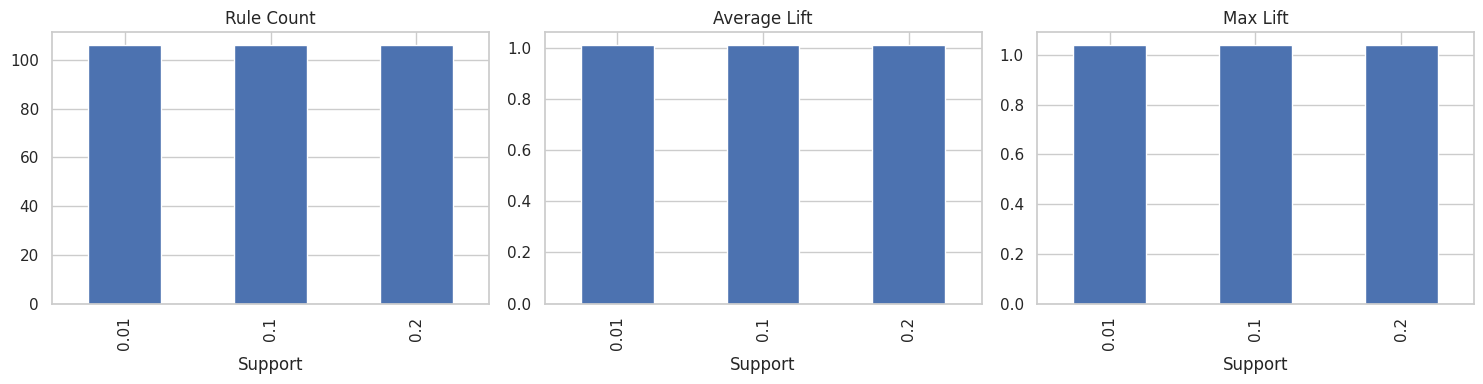

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
comparison['Rules'].plot(kind='bar', ax=ax[0], title='Rule Count')
comparison['Avg_Lift'].plot(kind='bar', ax=ax[1], title='Average Lift')
comparison['Max_Lift'].plot(kind='bar', ax=ax[2], title='Max Lift')
plt.tight_layout()

In [ ]:
print("=== Support 0.01 Top Rules ===")
print(rules_001.sort_values('lift', ascending=False).head(3))

print("\n=== Support 0.1 Top Rules ===")
print(rules_01.sort_values('lift', ascending=False).head(3))

print("\n=== Support 0.2 Top Rules ===")
print(rules_02.sort_values('lift', ascending=False).head(3))

=== Support 0.01 Top Rules ===
         antecedents       consequents  antecedent support  \
63  (dress, sweater)    (shoes, jeans)                0.61   
58    (shoes, jeans)  (dress, sweater)                0.82   
62  (jeans, sweater)    (shoes, dress)                0.71   

    consequent support  support  confidence      lift  representativity  \
63                0.82     0.52    0.852459  1.039584               1.0   
58                0.61     0.52    0.634146  1.039584               1.0   
62                0.71     0.52    0.732394  1.031541               1.0   

    leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
63    0.0198    1.220000       0.097633  0.571429   0.180328    0.743303  
58    0.0198    1.066000       0.211538  0.571429   0.061914    0.743303  
62    0.0159    1.083684       0.105438  0.577778   0.077222    0.732394  

=== Support 0.1 Top Rules ===
         antecedents       consequents  antecedent support  \
63  (dress, sweater)    (s

Since 0.001,0.1,0.2 support values have similar rule count ,avergae lift and maximum lift .We can choose any values among these three.

In [ ]:
# Displaying the top 10 frequent itemsets based on support
frequent_items.sort_values(by='support', ascending=False).head(10)

,support,itemsets
1,0.91,(jeans)
2,0.90,(shoes)
4,0.84,(t-shirt)
9,0.82,"(shoes, jeans)"
0,0.79,(dress)
11,0.77,"(t-shirt, jeans)"
3,0.77,(sweater)
13,0.74,"(shoes, t-shirt)"
5,0.73,"(jeans, dress)"
6,0.71,"(shoes, dress)"


In [ ]:
#  Generate rules with min confidence 0.3
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)



In [ ]:
#Displaying some rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,(jeans),(dress),0.73,0.802198,1.015440
1,(dress),(jeans),0.73,0.924051,1.015440
2,(shoes),(dress),0.71,0.788889,0.998594
3,(dress),(shoes),0.71,0.898734,0.998594
4,(dress),(sweater),0.61,0.772152,1.002795


In [ ]:
# After analyzing the comparison table,choosing  0.1 as support level and standard for our dataset.
final_support = 0.1
final_freq_items = apriori(df_encoded, min_support=final_support, use_colnames=True)


final_rules = association_rules(final_freq_items, metric="confidence", min_threshold=0.3)

print(f"\n--- Final Rules (Support={final_support}, Confidence>0.3) ---")
print(final_rules.head())


--- Final Rules (Support=0.1, Confidence>0.3) ---
  antecedents consequents  antecedent support  consequent support  support  \
0     (jeans)     (dress)                0.91                0.79     0.73   
1     (dress)     (jeans)                0.79                0.91     0.73   
2     (shoes)     (dress)                0.90                0.79     0.71   
3     (dress)     (shoes)                0.79                0.90     0.71   
4     (dress)   (sweater)                0.79                0.77     0.61   

   confidence      lift  representativity  leverage  conviction  \
0    0.802198  1.015440               1.0    0.0111    1.061667   
1    0.924051  1.015440               1.0    0.0111    1.185000   
2    0.788889  0.998594               1.0   -0.0010    0.994737   
3    0.898734  0.998594               1.0   -0.0010    0.987500   
4    0.772152  1.002795               1.0    0.0017    1.009444   

   zhangs_metric   jaccard  certainty  kulczynski  
0       0.168950  0.75257

In [ ]:
#Step 3:Visualizations

!pip install seaborn


In [ ]:
# Installing seaborn style (optional since import already changes look)
sns.set(style="whitegrid")

In [ ]:
# Selecting top 10 frequent itemsets
top_items = frequent_items.nlargest(10, 'support').copy()
top_items['itemsets'] = top_items['itemsets'].apply(lambda x: ', '.join(list(x)))

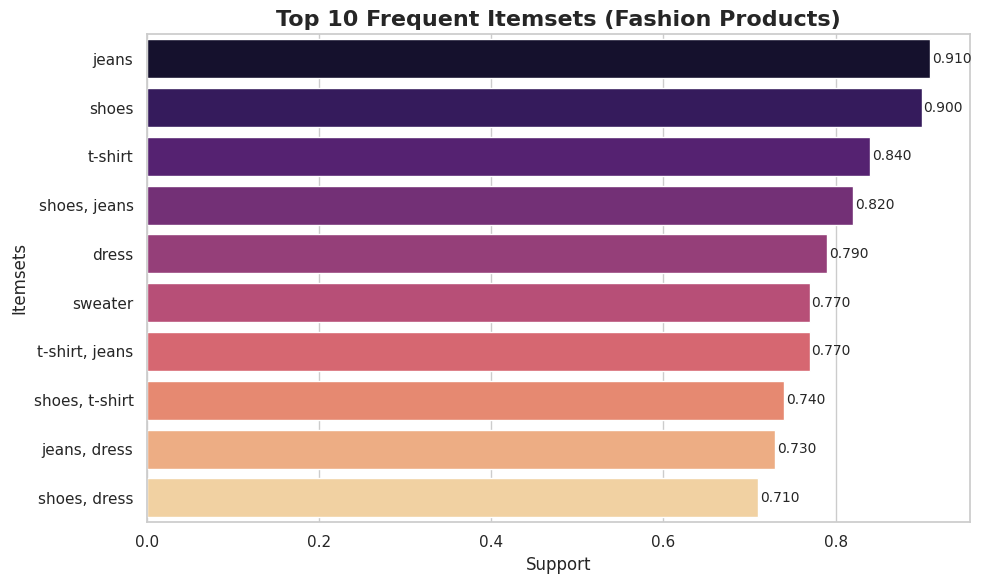

In [ ]:
# Creating the barplot with `hue` and no legend
plt.figure(figsize=(10, 6))
plot = sns.barplot(
    data=top_items,
    x='support',
    y='itemsets',
    hue='itemsets',        # <-- Fix: use hue for coloring
    dodge=False,
    palette='magma',
    legend=False           # <-- Fix: avoid unnecessary legend
)

# Adding value labels to each bar
for i, (support, label) in enumerate(zip(top_items['support'], top_items['itemsets'])):
    plt.text(support + 0.002, i, f"{support:.3f}", va='center', fontsize=10)

# Adding titles and labels
plt.title('Top 10 Frequent Itemsets (Fashion Products)', fontsize=16, fontweight='bold')
plt.xlabel('Support')
plt.ylabel('Itemsets')

# Optimizing layout
plt.tight_layout()
plt.show()

### Bar Graph

We can see that jeans have highest support meaning the frequency of jeans is very high which is 0.910 then our last fashion items are the combination of shoes and dress meaning their purchase history frequency together is very low which is 0.710 compared to the whole fashion items on our dataset .

We included individual items and item pairs of two to see which one performed the best as we can see individual items performed the best as compared to the paired itmes where paired items has t-shirt and jeans as the highest of 0.770 and shoes and dresses of lowest of 0.710 support , the individual has the highest jeans fo 0.910 support and the lowest sweaterof 0.770 support.



### Stakeholder Insight
Stakeholders should now have a clear focus on jeans fashion item for their costumers since it is the most loved and frequently brought by our custumers with the support of 0.910.
So if the stakeholder are focusing in one individual items or solo marketing launch focus they should focus on jeans inventory as they show the highest custumer demand but if they are focusing on promoting paired items for more profit or Style-based campagin launch they should focus on t-shirt and jeans pair since it has the highest support among all the pairs as shown on the bar graph above.




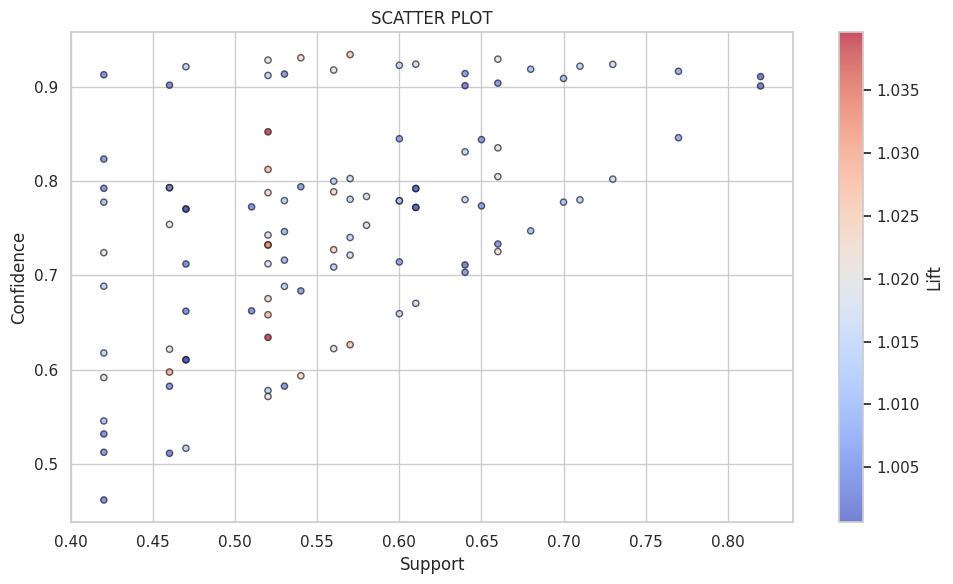

In [ ]:
# Creating a scatter plot of support vs confidence with lift as bubble size
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.7,
            s=rules['lift'] * 20, c=rules['lift'], cmap='coolwarm', edgecolors='k')
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('SCATTER PLOT')
plt.grid(True)
plt.tight_layout()
plt.show()


###  Scatter Plot Analysis: Association Rules (Support vs Confidence)

**Scatter Plot**


- **Confidence** (Y-axis):How reliable is the rule as in how often is the consequent true when the antecedent is true.
-**In diagram**:If it points high on Y-axis our confidence on the certainity that the customer will often buy B item when they buy item A is high whereas if it points on the x-axis our confidence is low .From the diagram we see that our value points high on y-axis so we have a high confidence

- **Support** (X-axis): How common the rule is among all the items transations


- **In diagram**:If it points to the right it means it is high in support but if it points to the left side it is low in support and it means that the frequency of the customer that buys item B after purchasing item A is low since in our scatter plot more dots are gravitated towards the left side.

- **Lift** (Bubble size and color): How much stronger is the association rule than random chance

- **In diagram**:Red and Warmer red and large dots size represent how strong is the non-random pattern than the random pattern by luck then by customers behaviour and actual predictable pattern.Here we can see from the diagram that our rules are confident but they are not much stronger than random chance and pattern.


###Stakeholders Insight

Our stakeholders can gain their trust on our model to make their critical businsess decisions and strategy with our scatter plot measuring the confidence which in our diagram is on a good side,support which is how frequent our transactions are which is low in accuracy and lastly lift which is how strong and reliable our patterns are which is good but not that strong than random chance so now our Stakeholders have an valuable insight to work and and rely on.
We can see that lift needs improvement meaning that our stakeholders now need to expand the range of trigger products or focus on making the main trigger product their priority or segment the dataset by brand or category to find stronger niche assocaitons between the fashion items.



Found 53 strong rules to visualize.


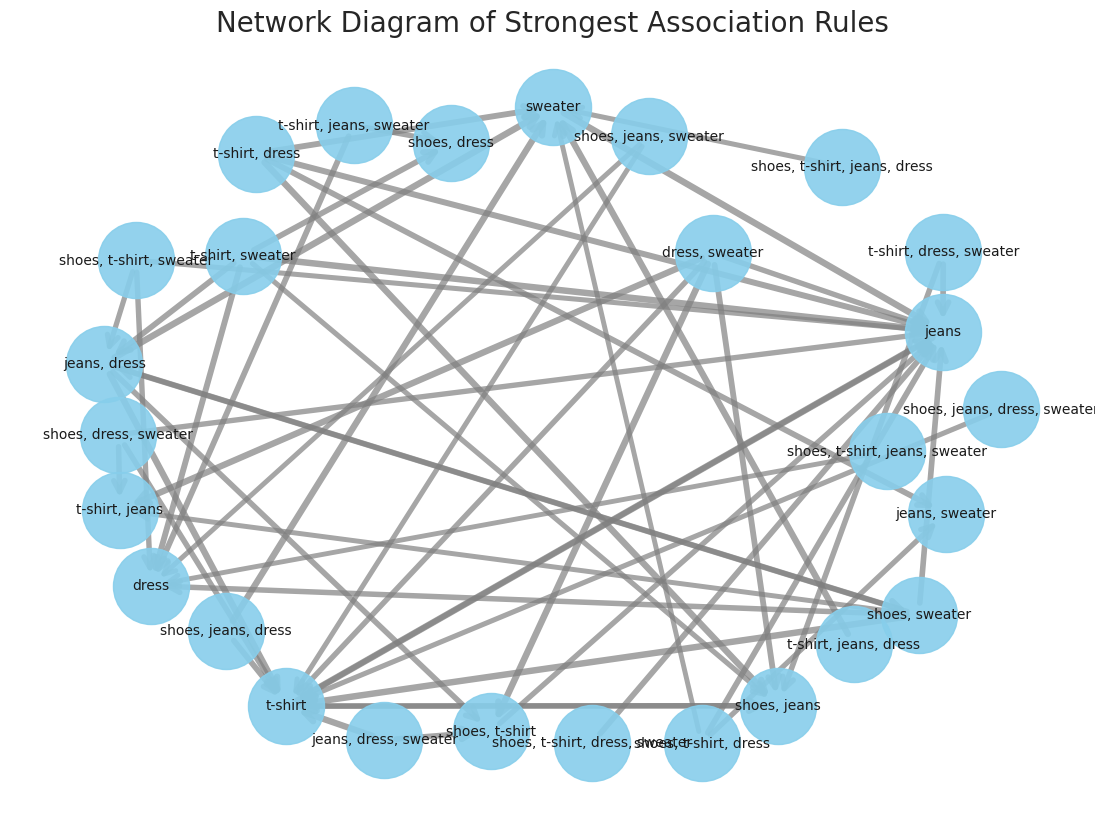

In [ ]:
print(f"Found {len(rules_filtered)} strong rules to visualize.")

    # --- Creating  Network Diagram ---
    # Creating a directed graph object
    G = nx.DiGraph()

    # Adding edges and nodes from the filtered rules
    for _, rule in rules_filtered.iterrows():
        # Getting antecedents and consequents as clean strings
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))

        # Adding the connection (edge) to the graph
        G.add_edge(antecedent, consequent, weight=rule['lift'])

    # Setting up the plot
    plt.figure(figsize=(14, 10))

    # Positioning the nodes using a spring layout for better readability
    pos = nx.spring_layout(G, k=3, seed=42) # 'k' adjusts spacing

    # Drawing the nodes
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue', alpha=0.9)

    # Drawing the edges (arrows) with width based on confidence
    edge_widths = [rules_filtered['confidence'].iloc[i] * 5 for i in range(len(G.edges()))]
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.7, edge_color='gray',
                             arrowstyle='->', arrowsize=20)

    # Drawing the labels on the nodes
    nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

    # Adding titles and turn off axes
    plt.title('Network Diagram of Strongest Association Rules', fontsize=20)
    plt.axis('off')
    plt.show()

##Network Diagmam

This diagram helps us to understand the relationships and flow of the items having the strongest association rules as we can see out of our 160 items ,53 items have strong assocation rule.

The blue circle represents the product wheraces the arrows represent the "if-then" rule where lets say if an dress is purchased then so is t-shirt ,jeans and sweater where the thickness of the arrow represents how strong its confidence is on the associations.

##Stakeholders Insight

It is easier to understand our complex association logic from a person who has no technical background .
It identifies the main trigger product which leads to the further purchases of other sub products where the more arrow points from the individual blue circle the more power and influence it has in trigger purchases just as we have in jeans circle the circle where it is the combination of two items as shoes ,jeans have less influence than an individual fashion item this shows our stakeholders the main fashion item to build an inventory and introduce a new stock to in their shop as it is the most preferreed and gateaway product to the custumers.

It allows business owner or manager to see the entire ecosystem of the product relationships to eachother.

In [ ]:
# Analyzing and interpreting rules
#Sorting rules by lift to find strongest associations
rules.sort_values(by='lift', ascending=False).head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
66,"(shoes, sweater)","(jeans, dress)",0.43750,0.45625,0.32500,0.742857,1.628180,1.0,0.125391,2.114583,0.685897,0.571429,0.527094,0.727593
67,"(jeans, dress)","(shoes, sweater)",0.45625,0.43750,0.32500,0.712329,1.628180,1.0,0.125391,1.955357,0.709549,0.571429,0.488584,0.727593
104,"(shoes, sweater)","(t-shirt, dress)",0.43750,0.41250,0.28750,0.657143,1.593074,1.0,0.107031,1.713542,0.661836,0.511111,0.416413,0.677056
105,"(t-shirt, dress)","(shoes, sweater)",0.41250,0.43750,0.28750,0.696970,1.593074,1.0,0.107031,1.856250,0.633673,0.511111,0.461279,0.677056
149,"(t-shirt, dress)","(shoes, jeans, sweater)",0.41250,0.40000,0.26250,0.636364,1.590909,1.0,0.097500,1.650000,0.632219,0.477273,0.393939,0.646307
132,"(shoes, jeans, sweater)","(t-shirt, dress)",0.40000,0.41250,0.26250,0.656250,1.590909,1.0,0.097500,1.709091,0.619048,0.477273,0.414894,0.646307
150,"(jeans, dress)","(shoes, t-shirt, sweater)",0.45625,0.36250,0.26250,0.575342,1.587152,1.0,0.097109,1.501210,0.680350,0.471910,0.333871,0.649740
131,"(shoes, t-shirt, sweater)","(jeans, dress)",0.36250,0.45625,0.26250,0.724138,1.587152,1.0,0.097109,1.971094,0.580299,0.471910,0.492667,0.649740
90,"(t-shirt, sweater)","(jeans, dress)",0.40625,0.45625,0.29375,0.723077,1.584826,1.0,0.108398,1.963542,0.621501,0.516484,0.490716,0.683456
91,"(jeans, dress)","(t-shirt, sweater)",0.45625,0.40625,0.29375,0.643836,1.584826,1.0,0.108398,1.667067,0.678650,0.516484,0.400144,0.683456


In [ ]:
# Finding rules where 'Dress' was the trigger item that lead to an consequent item purchase
rules[rules['antecedents'].apply(lambda x: 'Dress' in x)]


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [ ]:
#FP-GROWTH

In [ ]:
#STEP 1
transactions = df.groupby('User ID')['Product Name'].apply(list).tolist()

In [ ]:
print("\n--- Sample Transactions (Products per User) ---")
# Displaying the first 5 transactions (baskets)
for i, t in enumerate(transactions[:5]):
    print(f"User (Transaction) {i+1}: {t}")


--- Sample Transactions (Products per User) ---
User (Transaction) 1: ['shoes', 't-shirt', 'sweater', 'dress', 'sweater', 't-shirt', 't-shirt', 'dress', 'shoes']
User (Transaction) 2: ['jeans', 'shoes', 'sweater', 'jeans', 'shoes', 'shoes', 'jeans', 't-shirt', 'jeans']
User (Transaction) 3: ['sweater', 't-shirt', 't-shirt', 'sweater', 'shoes', 'dress', 'shoes', 'sweater', 'jeans', 'shoes', 'jeans']
User (Transaction) 4: ['sweater', 'dress', 'jeans', 'dress', 'shoes', 't-shirt', 'dress', 't-shirt', 't-shirt', 'shoes', 'jeans', 't-shirt']
User (Transaction) 5: ['shoes', 'jeans', 'shoes', 'dress', 'jeans', 'jeans', 'dress', 'shoes']


In [ ]:
# --- Step 2: One-Hot Encode the Transactions ---

# The fpgrowth function requires the data in a one-hot encoded format.
# Each row is a transaction, each column is an item.
# The value is 1 if the item is in the transaction, 0 otherwise.
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

print("\n--- One-Hot Encoded Data Sample ---")
print(df_onehot.head())


--- One-Hot Encoded Data Sample ---
   dress  jeans  shoes  sweater  t-shirt
0   True  False   True     True     True
1  False   True   True     True     True
2   True   True   True     True     True
3   True   True   True     True     True
4   True   True   True    False    False


In [ ]:
# --- Step 3: Run the FP-Growth Algorithm ---

# We now apply FP-Growth to find itemsets with a support of at least 8% (0.08).
# This means the itemset must appear in at least 8% of all user transactions.
# We choose 0.08 as a starting point to get a reasonable number of results.
min_support_threshold = 0.08
frequent_itemsets = fpgrowth(df_onehot, min_support=min_support_threshold, use_colnames=True)

print(f"\n--- Frequent Itemsets (Support >= {min_support_threshold}) ---")
print(f"\n--- Frequent Itemsets (Support >= {min_support_threshold}) ---")
# Sort by support for readability
print(frequent_itemsets.sort_values('support', ascending=False))


--- Frequent Itemsets (Support >= 0.08) ---

--- Frequent Itemsets (Support >= 0.08) ---
    support                                 itemsets
4      0.91                                  (jeans)
0      0.90                                  (shoes)
1      0.84                                (t-shirt)
5      0.82                           (shoes, jeans)
2      0.79                                  (dress)
3      0.77                                (sweater)
7      0.77                         (t-shirt, jeans)
6      0.74                         (shoes, t-shirt)
11     0.73                           (jeans, dress)
9      0.71                           (shoes, dress)
19     0.71                         (jeans, sweater)
16     0.70                         (shoes, sweater)
8      0.68                  (shoes, t-shirt, jeans)
10     0.66                         (t-shirt, dress)
12     0.66                    (shoes, jeans, dress)
17     0.65                       (t-shirt, sweater)
20     0.

In [ ]:
# Finally, we generate rules from our frequent itemsets.
# We'll use 'lift' as our metric. Lift > 1 indicates a positive correlation.
# A higher lift means the items are more likely to be bought together than expected.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

In [ ]:
# Sort the rules by lift and confidence for the most interesting results
final_rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

In [ ]:
print("\n--- Top 10 Generated Association Rules (Sorted by Lift) ---")
print(final_rules.head(10))


--- Top 10 Generated Association Rules (Sorted by Lift) ---
                antecedents              consequents  antecedent support  \
73         (dress, sweater)           (shoes, jeans)                0.61   
68           (shoes, jeans)         (dress, sweater)                0.82   
69           (shoes, dress)         (jeans, sweater)                0.71   
72         (jeans, sweater)           (shoes, dress)                0.71   
78  (shoes, t-shirt, dress)                (sweater)                0.58   
85                (sweater)  (shoes, t-shirt, dress)                0.77   
65  (shoes, jeans, sweater)                  (dress)                0.64   
76                  (dress)  (shoes, jeans, sweater)                0.79   
60         (dress, sweater)                  (jeans)                0.61   
61                  (jeans)         (dress, sweater)                0.91   

    consequent support  support  confidence      lift  representativity  \
73                0.82     

In [ ]:
# Step 4:Let's interpret the top rule
if not final_rules.empty:
    top_rule = final_rules.iloc[0]
    antecedent = list(top_rule['antecedents'])[0]
    consequent = list(top_rule['consequents'])[0]
    support = top_rule['support'] * 100
    confidence = top_rule['confidence'] * 100
    lift = top_rule['lift']

    print("\n--- Interpretation of the Top Rule ---")
    print(f"Rule: If a user buys '{antecedent}', they are likely to also buy '{consequent}'.")
    print(f"Support: This combination appears in {support:.2f}% of all user transactions.")
    print(f"Confidence: When a user buys '{antecedent}', there is a {confidence:.2f}% chance they will also buy '{consequent}'.")
    print(f"Lift: A user is {lift:.2f} times more likely to buy '{consequent}' if they have already bought '{antecedent}' (compared to the average user).")


--- Interpretation of the Top Rule ---
Rule: If a user buys 'dress', they are likely to also buy 'shoes'.
Support: This combination appears in 52.00% of all user transactions.
Confidence: When a user buys 'dress', there is a 85.25% chance they will also buy 'shoes'.
Lift: A user is 1.04 times more likely to buy 'shoes' if they have already bought 'dress' (compared to the average user).


In [ ]:
#BRUTE FORCE ALGORITHMN

In [ ]:
csv_data = """User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
... (all 1000 rows of your fashion data) ...
"""
df = pd.read_csv(StringIO(csv_data))

In [ ]:
# This line specifically uses your 'User ID' and 'Product Name' columns
transactions_list = df.groupby('User ID')['Product Name'].apply(list).tolist()

In [ ]:
# Converting list of lists to a list of sets for efficient subset checking
transactions_sets = [set(t) for t in transactions_list]
total_transactions = len(transactions_sets)

In [ ]:
# Get all unique items from the dataset
unique_items = sorted([item for sublist in transactions_sets for item in sublist])

In [ ]:
# --- Brute-Force Algorithm Implementation ---

def brute_force_frequent_itemsets(transactions, min_support):
    """
    Finds frequent itemsets using a brute-force approach.

    Args:
        transactions (list of sets): A list where each element is a set of items in a transaction.
        min_support (float): The minimum support threshold.

    Returns:
        pd.DataFrame: A DataFrame with 'support' and 'itemsets' columns.
    """
    unique_items = sorted(list(set(item for trans in transactions for item in trans)))
    itemset_counts = {}

    # 1. Generating every possible combination (itemset)
    for k in range(1, len(unique_items) + 1):
        # Generate all combinations of size k
        for itemset_tuple in combinations(unique_items, k):
            itemset = frozenset(itemset_tuple) # Use frozenset as it's hashable
            itemset_counts[itemset] = 0

      # 2. Count its occurrences across all transactions
            for transaction in transactions:
                if itemset.issubset(transaction):
                    itemset_counts[itemset] += 1


        # 3. Calculate support and filter
    frequent_items = []
    for itemset, count in itemset_counts.items():
        support = count / total_transactions
        if support >= min_support:
            frequent_items.append({'support': support, 'itemsets': itemset})

    return pd.DataFrame(frequent_items)

In [ ]:
# --- Running the Brute-Force Algorithm ---
print("Running Brute-Force Algorithm (this may take a moment)...")
start_time = time.time()
brute_force_results = brute_force_frequent_itemsets(transactions_sets, min_support=0.2)
brute_force_time = time.time() - start_time
print(f"Brute-Force completed in {brute_force_time:.4f} seconds.")
print("\n--- Brute-Force Top Frequent Itemsets ---")
print(brute_force_results.sort_values('support', ascending=False).head())

Running Brute-Force Algorithm (this may take a moment)...
Brute-Force completed in 0.0007 seconds.

--- Brute-Force Top Frequent Itemsets ---
   support itemsets
0      1.0    (nan)


In [ ]:
#COMPARISIONS

In [ ]:
# --- Preparing data for mlxtend algorithms ---
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
MIN_SUPPORT = 0.1

In [ ]:
# --- Time Brute-Force ---
print("1. Timing Brute-Force...")
start_bf = time.time()
brute_force_frequent_itemsets(transactions_sets, min_support=MIN_SUPPORT)
time_bf = time.time() - start_bf
print(f"   Done in {time_bf:.4f} seconds.\n")

1. Timing Brute-Force...
   Done in 0.0006 seconds.



In [ ]:
# --- Time Apriori ---
print("2. Timing Apriori...")
start_ap = time.time()
apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
time_ap = time.time() - start_ap
print(f"   Done in {time_ap:.4f} seconds.\n")

2. Timing Apriori...
   Done in 0.0020 seconds.



In [ ]:
# --- Time FP-Growth ---
print("3. Timing FP-Growth...")
start_fp = time.time()
fpgrowth(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
time_fp = time.time() - start_fp
print(f"   Done in {time_fp:.4f} seconds.\n")

3. Timing FP-Growth...
   Done in 0.0024 seconds.



--- Comparing Algorithms with MIN_SUPPORT = 0.2 ---

Running Brute-Force (this will be the slowest)...
Brute-Force finished in 0.0016s, Peak Memory: 0.0118 MB

Running Apriori...
Apriori finished in 0.0053s, Peak Memory: 0.0165 MB

Running FP-Growth...
FP-Growth finished in 0.0042s, Peak Memory: 0.0131 MB


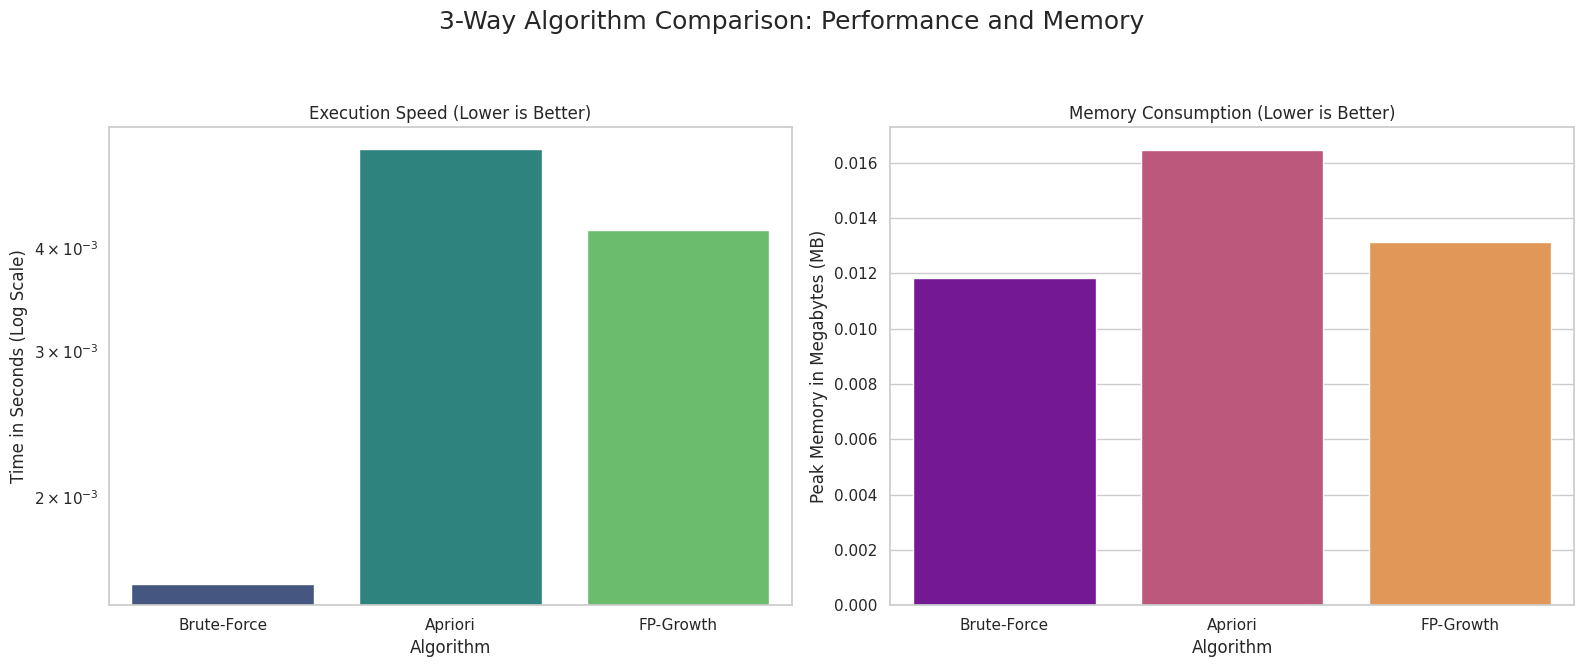

In [ ]:

import tracemalloc
from itertools import combinations

# --- Step 1: Reload and Prepare Data BY BRAND ---
# This ensures we have a clean slate for the test.
csv_data = """User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
... (rest of your CSV data) ...
"""
df = pd.read_csv(StringIO(csv_data))
brand_transactions = df.groupby('User ID')['Brand'].apply(lambda x: list(set(x.dropna()))).tolist()
transactions_sets = [set(t) for t in brand_transactions if t] # Filter out empty lists

# Prepare one-hot encoded data for mlxtend algorithms
te_brand = TransactionEncoder()
te_ary_brand = te_brand.fit(transactions_sets).transform(transactions_sets)
df_encoded_brand = pd.DataFrame(te_ary_brand, columns=te_brand.columns_)


# --- Brute-Force Algorithm Function (required for the test) ---
def brute_force_frequent_itemsets(transactions, min_support):
    unique_items = sorted(list(set(item for trans in transactions for item in trans)))
    itemset_counts = {}
    total_transactions = len(transactions)
    for k in range(1, len(unique_items) + 1):
        for itemset_tuple in combinations(unique_items, k):
            itemset = frozenset(itemset_tuple)
            itemset_counts[itemset] = 0
            for transaction in transactions:
                if itemset.issubset(transaction):
                    itemset_counts[itemset] += 1
    frequent_items = []
    for itemset, count in itemset_counts.items():
        support = count / total_transactions
        if support >= min_support:
            frequent_items.append({'support': support, 'itemsets': itemset})
    return pd.DataFrame(frequent_items)


# --- Step 2: The Comparison Test ---
# Using a high support level so Brute-Force can complete.
MIN_SUPPORT = 0.2
results_list = []

print(f"--- Comparing Algorithms with MIN_SUPPORT = {MIN_SUPPORT} ---")

# Test 1: Brute-Force
print("\nRunning Brute-Force (this will be the slowest)...")
tracemalloc.start()
start_time = time.time()
brute_force_frequent_itemsets(transactions_sets, min_support=MIN_SUPPORT)
end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
results_list.append({
    'Algorithm': 'Brute-Force',
    'Time (s)': end_time - start_time,
    'Peak Memory (MB)': peak / 1024**2
})
print(f"Brute-Force finished in {results_list[0]['Time (s)']:.4f}s, Peak Memory: {results_list[0]['Peak Memory (MB)']:.4f} MB")

# Test 2: Apriori
print("\nRunning Apriori...")
tracemalloc.start()
start_time = time.time()
apriori(df_encoded_brand, min_support=MIN_SUPPORT, use_colnames=True)
end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
results_list.append({
    'Algorithm': 'Apriori',
    'Time (s)': end_time - start_time,
    'Peak Memory (MB)': peak / 1024**2
})
print(f"Apriori finished in {results_list[1]['Time (s)']:.4f}s, Peak Memory: {results_list[1]['Peak Memory (MB)']:.4f} MB")

# Test 3: FP-Growth
print("\nRunning FP-Growth...")
tracemalloc.start()
start_time = time.time()
fpgrowth(df_encoded_brand, min_support=MIN_SUPPORT, use_colnames=True)
end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
results_list.append({
    'Algorithm': 'FP-Growth',
    'Time (s)': end_time - start_time,
    'Peak Memory (MB)': peak / 1024**2
})
print(f"FP-Growth finished in {results_list[2]['Time (s)']:.4f}s, Peak Memory: {results_list[2]['Peak Memory (MB)']:.4f} MB")


# --- Step 3: Visualize the Full Comparison ---
results_df = pd.DataFrame(results_list)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-Way Algorithm Comparison: Performance and Memory', fontsize=18)

# Plot 1: Execution Time
sns.barplot(ax=axes[0], x='Algorithm', y='Time (s)', data=results_df, palette='viridis')
axes[0].set_title('Execution Speed (Lower is Better)')
axes[0].set_ylabel('Time in Seconds (Log Scale)')
axes[0].set_yscale('log')  # Log scale is essential to see the differences

# Plot 2: Peak Memory Usage
sns.barplot(ax=axes[1], x='Algorithm', y='Peak Memory (MB)', data=results_df, palette='plasma')
axes[1].set_title('Memory Consumption (Lower is Better)')
axes[1].set_ylabel('Peak Memory in Megabytes (MB)')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()